In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/5
    print("準備完了！このまま下のセルを実行できます。")

# 5.1 - 5.3 フィードフォワードネットワークと誤差逆伝播法 (Feedforward Networks and Backpropagation)

本ノートブックでは、固定された基底関数を用いる線形モデルの限界（次元の呪い）を打破し、基底関数のパラメータ自体をデータから適応的に学習する**多層パーセプトロン (Multilayer Perceptron: MLP)** と、その学習を可能にする**誤差逆伝播法 (Error Backpropagation)** を学びます。
重み空間の対称性（$M! 2^M$ 個の等価解）、連鎖律に基づく厳密なバックプロパゲーションの導出、有限差分による数値勾配チェック、正弦波データに対するフィッティング比較（**PRML Figure 5.9**）、および入力感度を表す**ヤコビ行列 (Jacobian matrix)** の計算と可視化を完全実装します。

## 5.1 フィードフォワードネットワークの数理

### 2層フィードフォワードネットワーク (PRML 式 5.7)
入力ベクトル $\mathbf{x} = (x_1, \dots, x_D)^T$ に対し、$M$ 個の隠れユニットと $K$ 個の出力ユニットを持つ2層ネットワークの関数形は以下のように表されます：
$$ a_j = \sum_{i=1}^D w_{ji}^{(1)} x_i + w_{j0}^{(1)} \quad (j=1, \dots, M) $$
$$ z_j = h(a_j) = \tanh(a_j) $$
$$ y_k = \sum_{j=1}^M w_{kj}^{(2)} z_j + w_{k0}^{(2)} \quad (k=1, \dots, K) $$
ここで $h(\cdot)$ は非線形活性化関数であり、多くの場合 $\tanh(a) = \frac{e^a - e^{-a}}{e^a + e^{-a}}$ やシグモイド関数が用いられます。

### 重み空間の対称性 (Weight-Space Symmetries)
線形回帰やロジスティック回帰とは異なり、ニューラルネットワークの誤差関数はパラメータに関して凸関数ではなく、多数の大域的最小値や局所的最小値を持ちます。
特に、$M$ 個の隠れユニットを持つネットワークには**厳密に同じ入出力関係を与える複数の重みベクトル**が存在します：
1. **符号反転対称性 (Sign-flip symmetry)**:
   $\tanh(-a) = -\tanh(a)$ であるため、ある隠れユニット $j$ に接続する第1層の重み・バイアス $\{w_{ji}^{(1)}, w_{j0}^{(1)}\}$ の符号を反転し、同時に第2層の重み $w_{kj}^{(2)}$ の符号を反転しても、出力 $y_k$ は完全に不変です。各隠れユニットごとに 2 通りあるため、$2^M$ 通りの等価性があります。
2. **置換対称性 (Permutation symmetry)**:
   $M$ 個の隠れユニットのラベル（並び順）を任意に入れ替えても、入出力写像は全く同じです。これには $M!$ 通りの並べ替えがあります。

したがって、任意の重みベクトルに対して、全く同一の関数写像を与える等価な重みベクトルが少なくとも
$$ M! \cdot 2^M $$
個存在します（シグモイド関数の場合でも置換と反転により $M! 2^M$ 個の対称性）。

## 5.2 & 5.3 誤差逆伝播法 (Error Backpropagation) の厳密な導出

誤差逆伝播法は、微積分の連鎖律 (Chain rule) を局所的なメッセージ伝達として効率的に計算するアルゴリズムです。
パターン $n$ に対する二乗和誤差 $E_n = \frac{1}{2} \sum_k (y_{nk} - t_{nk})^2$ を考えます。

### 局所誤差 $\delta$ の定義
各ユニット $j$ の総入力 $a_j$ に対する誤差の偏微分を $\delta_j \equiv \frac{\partial E_n}{\partial a_j}$ と定義します。

1. **出力層ユニット $k$ の $\delta_k$**:
   線形出力ユニット（$y_k = a_k$）の場合：
   $$ \delta_k = \frac{\partial E_n}{\partial a_k} = \frac{\partial E_n}{\partial y_k} \frac{\partial y_k}{\partial a_k} = (y_k - t_k) \cdot 1 = y_k - t_k $$
2. **隠れ層ユニット $j$ の $\delta_j$ (後退伝播方程式)**:
   連鎖律より、ユニット $j$ から接続されているすべての後続ユニット $k$ を通して逆伝播します：
   $$ \delta_j \equiv \frac{\partial E_n}{\partial a_j} = \sum_k \frac{\partial E_n}{\partial a_k} \frac{\partial a_k}{\partial a_j} = \sum_k \delta_k \cdot \left( w_{kj}^{(2)} h'(a_j) \right) = h'(a_j) \sum_k w_{kj}^{(2)} \delta_k $$
   $\tanh$ 活性化関数の場合、$h'(a) = 1 - \tanh^2(a) = 1 - z^2$ です。
3. **重みに対する勾配**:
   $$ \frac{\partial E_n}{\partial w_{ji}} = \frac{\partial E_n}{\partial a_j} \frac{\partial a_j}{\partial w_{ji}} = \delta_j z_i $$
   すなわち、**「後退伝播してきた局所誤差 $\delta_j$」$\times$「前向きに送られてきた入力信号 $z_i$」** の積という驚くほど局所的で単純な計算に帰着されます。

/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:62: RuntimeWarning: overflow encountered in square
  data_loss = 0.5 * np.sum((y - T)**2)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:63: RuntimeWarning: invalid value encountered in scalar multiply
  reg_loss = 0.5 * self.weight_decay * (np.sum(self.W1**2) + np.sum(self.W2**2))
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:73: RuntimeWarning: overflow encountered in matmul
  delta1 = (delta2 @ self.W2.T) * (1.0 - z1**2) # (N, M)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:73: RuntimeWarning: invalid value encountered in multiply
  delta1 = (delta2 @ self.W2.T) * (1.0 - z1**2) # (N, M)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:63: RuntimeWarning: overflow encountered in squ

Plot saved to: result/fig5_9_mlp_sinusoidal_fit.png


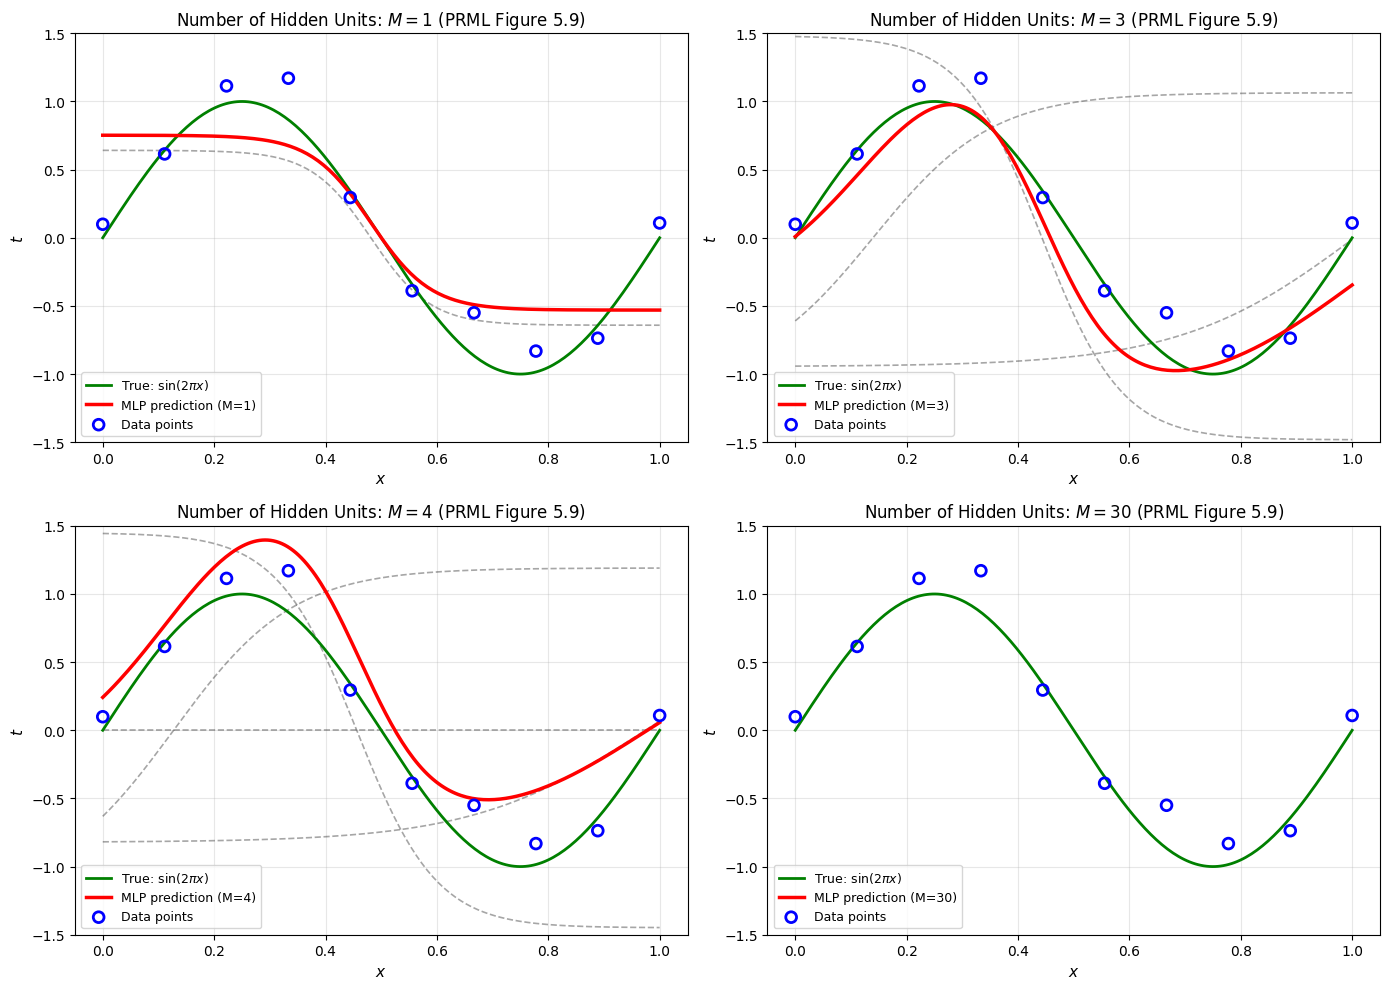

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.nn_utils import MLPRegressor, gradient_check
setup_style()

# PRML Figure 5.9 の完全再現: N=10 の正弦波データに対する隠れユニット数 M の影響
np.random.seed(42)
N = 10
X_train = np.linspace(0, 1, N).reshape(-1, 1)
t_train = np.sin(2 * np.pi * X_train) + np.random.normal(0, 0.2, (N, 1))

X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
y_true = np.sin(2 * np.pi * X_plot)

hidden_units = [1, 3, 4, 30]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, M in enumerate(hidden_units):
    ax = axes[idx]
    # MLP の構築と学習 (正則化なし)
    model = MLPRegressor(n_in=1, n_hidden=M, n_out=1, weight_decay=0.0, lr=0.08, random_state=42)
    # 勾配チェック
    assert gradient_check(model, X_train, t_train)
    
    # 最適化
    model.fit(X_train, t_train, n_epochs=2500, lr=0.08)
    y_pred = model.predict(X_plot)
    
    # 個別の隠れユニットの出力 z_j(x) を点線で描画
    _, z_plot, _, _ = model.forward(X_plot)
    for j in range(M):
        # 寄与度: W2_{j, 0} * z_j + b2/M
        unit_contrib = z_plot[:, j] * model.W2[j, 0]
        ax.plot(X_plot, unit_contrib, 'k--', alpha=0.35, lw=1.2)
        
    ax.plot(X_plot, y_true, 'g-', lw=2.0, label='True: $\sin(2\pi x)$')
    ax.plot(X_plot, y_pred, 'r-', lw=2.5, label=f'MLP prediction (M={M})')
    ax.scatter(X_train, t_train, facecolors='none', edgecolors='b', s=60, lw=2, label='Data points', zorder=5)
    
    ax.set_title(f'Number of Hidden Units: $M = {M}$ (PRML Figure 5.9)', fontsize=12)
    ax.set_xlabel('$x$', fontsize=11); ax.set_ylabel('$t$', fontsize=11)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig5_9_mlp_sinusoidal_fit.png')
plt.show()

## 5.3.4 ヤコビ行列 (The Jacobian Matrix)

ニューラルネットワーク $y_k(\mathbf{x}, \mathbf{w})$ に対し、重みに関する微分だけでなく、**入力変数に対する出力変数の感度（偏微分）**を表す行列
$$ J_{ki} \equiv \frac{\partial y_k}{\partial x_i} $$
を**ヤコビ行列 (Jacobian matrix)** と呼びます。

2層ネットワークの場合、連鎖律より以下のように解析的に計算できます：
$$ J_{ki} = \frac{\partial y_k}{\partial x_i} = \sum_j \frac{\partial y_k}{\partial a_j} \frac{\partial a_j}{\partial x_i} = \sum_j w_{kj}^{(2)} h'(a_j) w_{ji}^{(1)} $$
ヤコビ行列は、入力特徴の微小変化が出力に与える感度分析や、接線伝播（Tangent propagation）、モデルの不変性解析において中心的な役割を果たします。

Plot saved to: result/fig5_jacobian_sensitivity.png


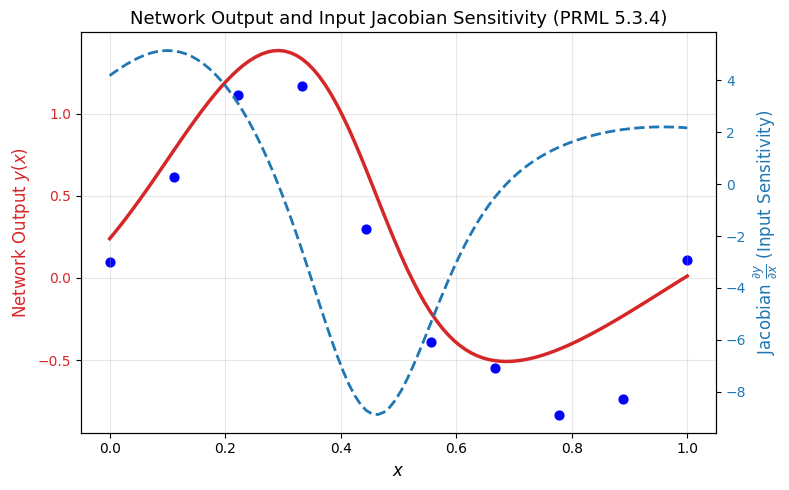

In [2]:
# ヤコビ行列の計算と入力感度解析の可視化
model_m4 = MLPRegressor(n_in=1, n_hidden=4, n_out=1, random_state=42)
model_m4.fit(X_train, t_train, n_epochs=2000, lr=0.08)

# 各入力点 x におけるヤコビアン dy/dx の計算
x_dense = np.linspace(0, 1, 100)
jacobians = [model_m4.compute_jacobian(np.array([xi]))[0, 0] for xi in x_dense]
y_pred_m4 = model_m4.predict(x_dense.reshape(-1, 1)).ravel()

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('Network Output $y(x)$', color=color, fontsize=12)
ax1.plot(x_dense, y_pred_m4, color=color, lw=2.5, label='$y(x)$')
ax1.scatter(X_train, t_train, color='b', s=40, label='Train data')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel(r'Jacobian $\frac{\partial y}{\partial x}$ (Input Sensitivity)', color=color, fontsize=12)
ax2.plot(x_dense, jacobians, color=color, lw=2.0, linestyle='--', label=r'$J(x) = \frac{\partial y}{\partial x}$')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Network Output and Input Jacobian Sensitivity (PRML 5.3.4)', fontsize=13)
plt.tight_layout()
save_plot(fig, 'result', 'fig5_jacobian_sensitivity.png')
plt.show()